In [18]:
import numpy as np
import pandas as pd
import bnlearn as bn
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from KbinsDiscretizer import *
from PlotsFunctions import * 
from DiscreteStructureLearning import *
from Pipeline import *
from Inference import *

In [8]:
import os
os.chdir('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI')

## **Heart Dataset**

In [9]:
# Load the dataset
heartdata = pd.read_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart.csv')

### **EDA**

This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

1. age
2. sex
3. chest pain type (4 values)
4. resting blood pressure
5. serum cholestoral in mg/dl
6. fasting blood sugar > 120 mg/dl
7. resting electrocardiographic results (values 0,1,2)
8. maximum heart rate achieved
9. exercise induced angina
10. oldpeak = ST depression induced by exercise relative to rest
11. the slope of the peak exercise ST segment
12. number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect


[Kaggle - Heart Disease Dataset, [https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)]

In [9]:
heartdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [10]:
heartdata.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
heart_cont = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
heart_disc = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

print('Continuous columns: ', heart_cont)
print('Discrete columns: ', heart_disc)

Continuous columns:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Discrete columns:  ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [11]:
# Split the dataset in train and test set
train_heart, test_heart = train_test_split(heartdata, test_size=0.2, random_state=7)

### **5-Fold Cross-Validation**

In [6]:
# Define the scoring functions for grid search
scoring = ['aic', 'bic','k2', 'bdeu']

# Split training set in 5 folds 
hkf = KFold(n_splits=5, shuffle=True, random_state=7)

# List of metrics of interest
metric_keys = [
    "Balanced Accuracy",
    "F1 Score",
    "AUC",
    "Brier Score",
    "KL Divergence",
    "Expected Calibration Loss",
    "Training Time (s)",
    "Inference Time (s)"
]

qui sotto faccio cross validation per Bayesian Network

In [66]:
all_results = {}
# Iterate over the scoring functions and for each of them perform cross-validation
for s in scoring: 

    # Initialize a dictionary to store the values per fold of each metric 
    results_summary = {key: [] for key in metric_keys}
    
    print(f"\n==================== SCORING: {s.upper()} ====================")

    n_folds = hkf.get_n_splits()

    for i, (train_idx, test_idx) in enumerate(hkf.split(train_heart), start=1):
        train_df = train_heart.iloc[train_idx]
        test_df = train_heart.iloc[test_idx]

        print(f"\n----- Fold {i}/{n_folds} -----")
        
        # Call BayesianNetworkPipeline using s as the scoring method for structure learning
        metrics = BayesianNetworkPipeline(train_df, test_df, heart_cont, nbins=[4,3,3,3,3], method='hc', scoring=s)

        # Extract values for metrics
        for key in metric_keys:

            # Extract numeric value from string
            if key in ["Training Time (s)", "Inference Time (s)"]:            
                value = float(metrics[key].replace(" s", "").strip())

            else: 
                value = float(metrics[key])
            
            # Append the metric 
            results_summary[key].append(value)
    
    # Compute the mean for each metric
    mean_metrics = {key: round(np.mean(values), 4) for key, values in results_summary.items()}
    all_results[s] = mean_metrics

# Summary of grid search
print("\n==================== FINAL SUMMARY ====================")
for s, metrics in all_results.items():
    print(f"\nScoring: {s.upper()}")
    for key, val in metrics.items():
        print(f"{key}: {val}")


==================== SCORING: AIC ====================

----- Fold 1/5 -----
[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x731b42d3a990>, 'model_edges': [('age', 'thalach'), ('age', 'oldpeak'), ('age', 'thal'), ('age', 'chol'), ('sex', 'cp'), ('cp', 'exang'), ('cp', 'thalach'), ('trestbps', 'age'), ('trestbps', 'cp'), ('trestbps', 'slope'), ('trestbps', 'fbs'), ('trestbps', 'chol'), ('chol', 'sex'), ('chol', 'exang'), ('fbs', 'thal'), ('fbs', 'slope'), ('fbs', 'age'), ('fbs', 'target'), ('thalach', 'restecg'), ('exang', 'restecg'), ('oldpeak', 'slope'), ('oldpeak', 'cp'), ('oldpeak', 'target'), ('slope', 'thalach'), ('slope', 'restecg'), ('slope', 'chol'), ('ca', 'target'), ('ca', 'age'), ('ca', 'trestbps'), ('ca', 'oldpeak'), ('thal', 'sex'), ('target

100%|██████████| 129/129 [00:00<00:00, 993.79it/s] 



----- Fold 2/5 -----
[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x731b2ab6f7d0>, 'model_edges': [('age', 'thal'), ('cp', 'exang'), ('cp', 'trestbps'), ('trestbps', 'age'), ('chol', 'ca'), ('chol', 'exang'), ('chol', 'restecg'), ('chol', 'sex'), ('chol', 'thalach'), ('chol', 'target'), ('chol', 'cp'), ('fbs', 'thal'), ('fbs', 'ca'), ('fbs', 'thalach'), ('fbs', 'target'), ('thalach', 'cp'), ('thalach', 'age'), ('thalach', 'restecg'), ('thalach', 'exang'), ('oldpeak', 'slope'), ('oldpeak', 'target'), ('oldpeak', 'cp'), ('oldpeak', 'chol'), ('slope', 'thalach'), ('slope', 'restecg'), ('slope', 'target'), ('slope', 'fbs'), ('ca', 'age'), ('ca', 'trestbps'), ('thal', 'sex'), ('target', 'cp'), ('target', 'thal'), ('target', 'ca'), ('target', 'exang'), ('targ

100%|██████████| 134/134 [00:00<00:00, 997.36it/s] 



----- Fold 3/5 -----
[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x731b2ab3cf90>, 'model_edges': [('age', 'thalach'), ('age', 'thal'), ('age', 'oldpeak'), ('cp', 'exang'), ('cp', 'thalach'), ('cp', 'oldpeak'), ('trestbps', 'age'), ('trestbps', 'cp'), ('trestbps', 'fbs'), ('chol', 'ca'), ('chol', 'sex'), ('chol', 'target'), ('fbs', 'thal'), ('fbs', 'exang'), ('thalach', 'restecg'), ('thalach', 'exang'), ('thalach', 'fbs'), ('exang', 'restecg'), ('oldpeak', 'thalach'), ('oldpeak', 'fbs'), ('slope', 'oldpeak'), ('slope', 'target'), ('slope', 'cp'), ('slope', 'restecg'), ('slope', 'trestbps'), ('slope', 'fbs'), ('slope', 'ca'), ('ca', 'age'), ('ca', 'trestbps'), ('thal', 'sex'), ('target', 'cp'), ('target', 'thal'), ('target', 'ca'), ('target', 'exang'), (

...


----- Fold 4/5 -----
[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bdeu]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x731b2ab6df50>, 'model_edges': [('age', 'trestbps'), ('sex', 'ca'), ('sex', 'chol'), ('sex', 'thal'), ('sex', 'slope'), ('cp', 'target'), ('cp', 'exang'), ('cp', 'thalach'), ('cp', 'oldpeak'), ('trestbps', 'fbs'), ('thalach', 'restecg'), ('exang', 'target'), ('exang', 'restecg'), ('exang', 'slope'), ('oldpeak', 'thal'), ('slope', 'oldpeak'), ('slope', 'thalach'), ('slope', 'restecg'), ('ca', 'age'), ('target', 'thal'), ('target', 'ca'), ('target', 'slope'), ('target', 'chol'), ('target', 'sex')], 'adjmat': target      age    sex     cp  trestbps   chol    fbs  restecg  thalach  \
source                                                                    
age       False  False  False    

100%|██████████| 133/133 [00:00<00:00, 973.96it/s]



----- Fold 5/5 -----
[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bdeu]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x731b2ab72a10>, 'model_edges': [('sex', 'chol'), ('sex', 'ca'), ('sex', 'slope'), ('cp', 'exang'), ('cp', 'oldpeak'), ('cp', 'trestbps'), ('trestbps', 'age'), ('trestbps', 'fbs'), ('chol', 'thalach'), ('fbs', 'thal'), ('thalach', 'restecg'), ('exang', 'slope'), ('exang', 'restecg'), ('slope', 'oldpeak'), ('slope', 'thalach'), ('slope', 'restecg'), ('ca', 'age'), ('thal', 'sex'), ('target', 'cp'), ('target', 'thal'), ('target', 'ca'), ('target', 'slope'), ('target', 'exang'), ('target', 'sex'), ('target', 'chol'), ('target', 'fbs')], 'adjmat': target      age    sex     cp  trestbps   chol    fbs  restecg  thalach  \
source                                                                 

100%|██████████| 127/127 [00:00<00:00, 991.23it/s]


==================== FINAL SUMMARY ====================

Scoring: AIC
Balanced Accuracy: 0.8855
F1 Score: 0.8881
AUC: 0.8855
Brier Score: 0.1158
KL Divergence: 0.0
Expected Calibration Loss: 0.3251
Training Time (s): 1.9082
Inference Time (s): 0.1481

Scoring: BIC
Balanced Accuracy: 0.8452
F1 Score: 0.8485
AUC: 0.8452
Brier Score: 0.1561
KL Divergence: 0.0
Expected Calibration Loss: 0.2868
Training Time (s): 0.3309
Inference Time (s): 0.1342

Scoring: K2
Balanced Accuracy: 0.9471
F1 Score: 0.9465
AUC: 0.9471
Brier Score: 0.0537
KL Divergence: 0.0
Expected Calibration Loss: 0.4929
Training Time (s): 67.2927
Inference Time (s): 1.7732

Scoring: BDEU
Balanced Accuracy: 0.8436
F1 Score: 0.8483
AUC: 0.8436
Brier Score: 0.1561
KL Divergence: 0.0
Expected Calibration Loss: 0.2753
Training Time (s): 0.5075
Inference Time (s): 0.1447


In [3]:
fold_results = {
    "AIC": {
        "Balanced Accuracy": [0.8855],
        "F1 Score": [0.8881],
        "AUC": [0.8855],
        "Brier Score": [0.1158],
        "KL Divergence": [0.0],
        "Expected Calibration Loss": [0.3251],
        "Training Time (s)": [1.9082],
        "Inference Time (s)": [0.1481]
    },
    "BIC": {
        "Balanced Accuracy": [0.8452],
        "F1 Score": [0.8485],
        "AUC": [0.8452],
        "Brier Score": [0.1561],
        "KL Divergence": [0.0],
        "Expected Calibration Loss": [0.2868],
        "Training Time (s)": [0.3309],
        "Inference Time (s)": [0.1342]
    },
    "K2": {
        "Balanced Accuracy": [0.9471],
        "F1 Score": [0.9465],
        "AUC": [0.9471],
        "Brier Score": [0.0537],
        "KL Divergence": [0.0],
        "Expected Calibration Loss": [0.4929],
        "Training Time (s)": [67.2927],
        "Inference Time (s)": [1.7732]
    },
    "BDEU": {
        "Balanced Accuracy": [0.8436],
        "F1 Score": [0.8483],
        "AUC": [0.8436],
        "Brier Score": [0.1561],
        "KL Divergence": [0.0],
        "Expected Calibration Loss": [0.2753],
        "Training Time (s)": [0.5075],
        "Inference Time (s)": [0.1447]
    }
}

In [4]:
# Plot metrics per fold per scoring function
plot_fold_metrics(fold_results, palette="tab10") 

TypeError: color_palette() got an unexpected keyword argument 'colors'

### **Pre-Processing**

Now, we train use the same pipeline using the best performing scoring method ($k2$) and we test on the unseen test data. 

In [12]:
# Fit the discretizer on the training set
discretizer_heart, train_dheart = discretize_fit(train_heart, heart_cont, [4,3,3,3,3], transform=True)

# Trasnsform the test set
test_dheart = discretize_transform(test_heart, heart_cont, discretizer_heart)

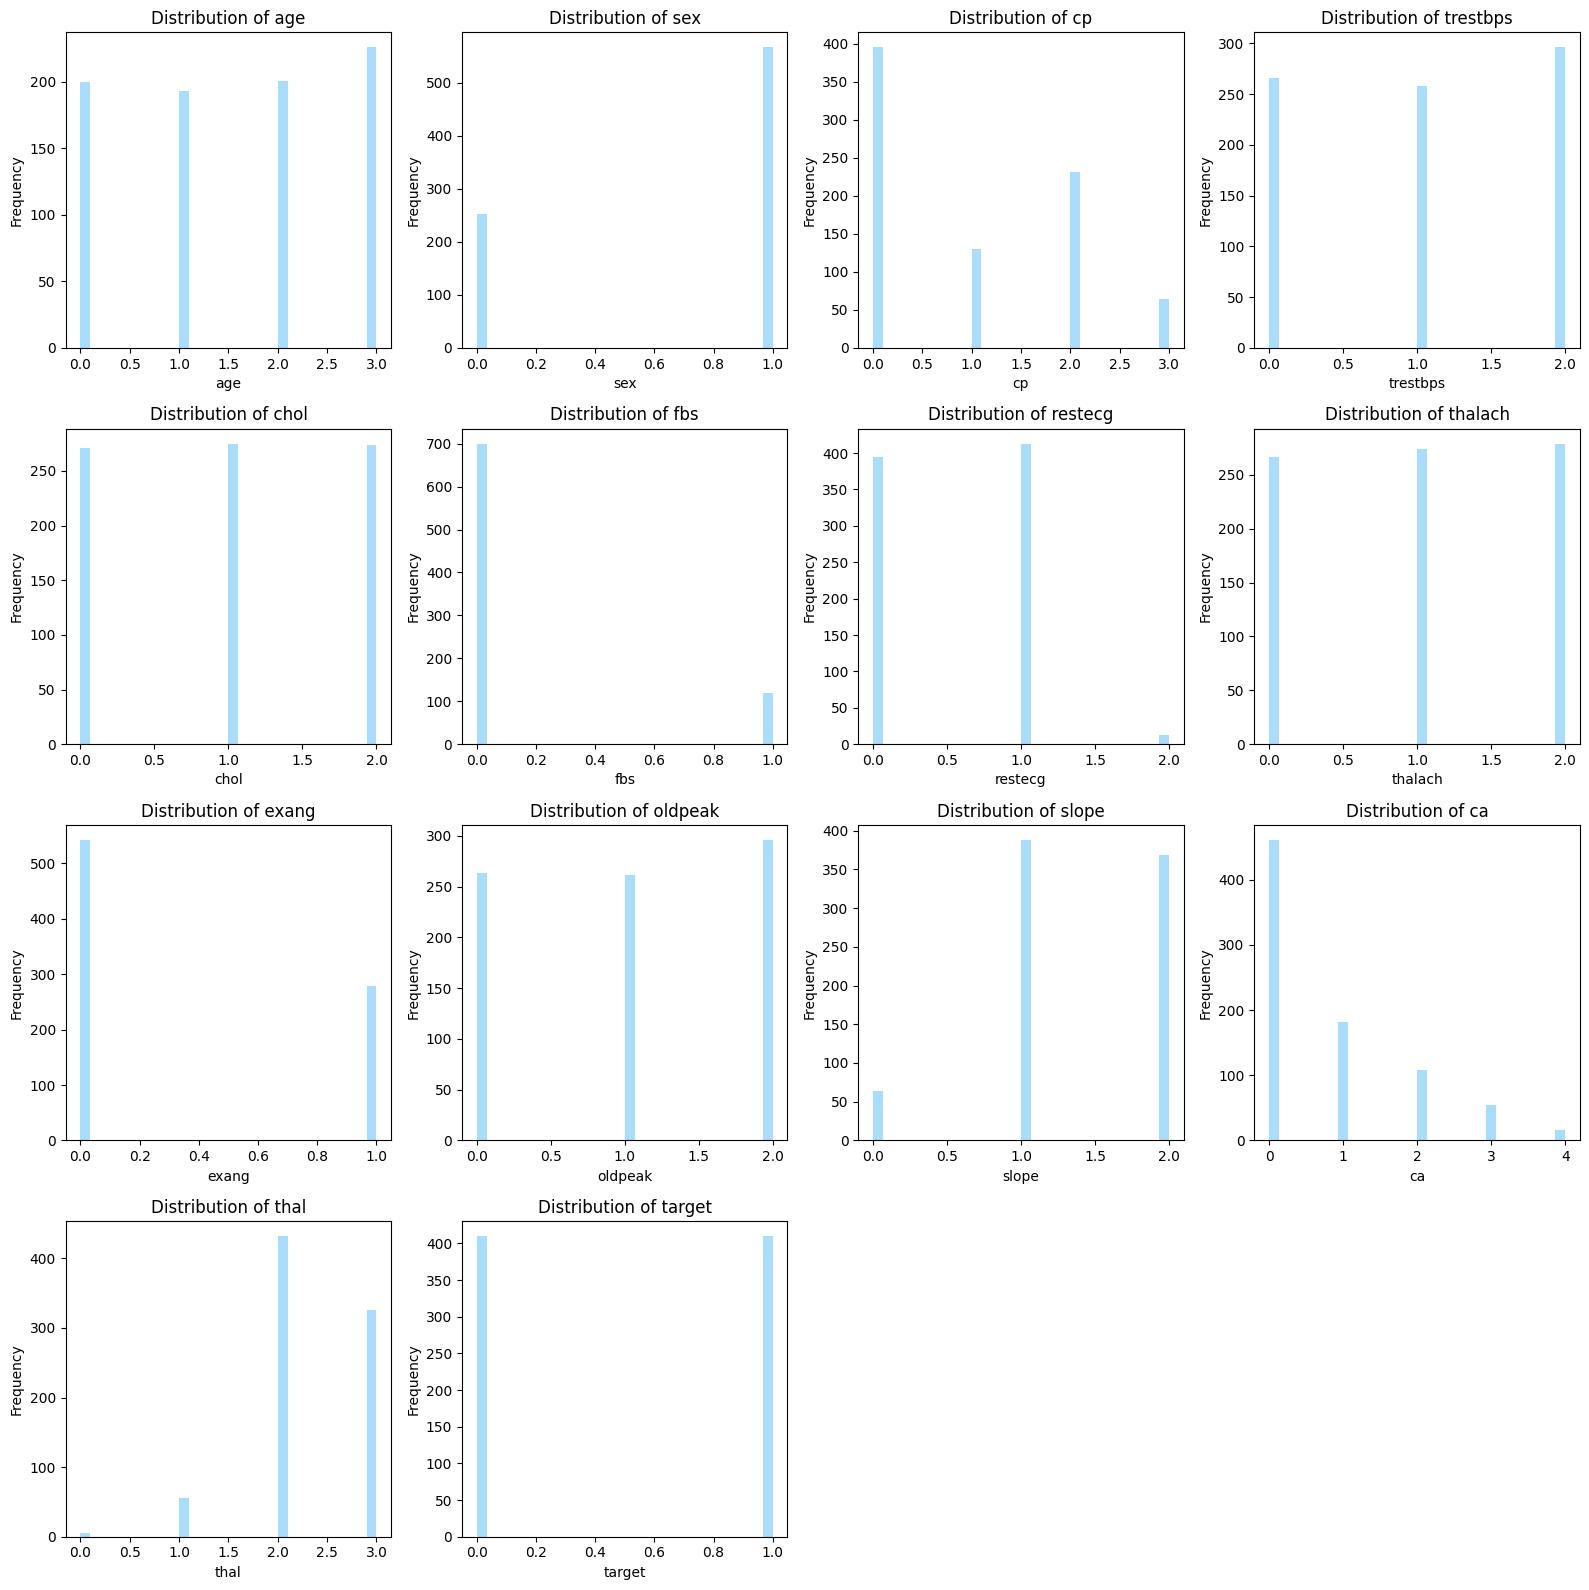

In [13]:
# Visualize the discretized variables in the train set:
plot_distributions(train_dheart, train_dheart.columns)


### **Structure and Parameter Learning**

[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [k2]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x71eefe2725d0>, 'model_edges': [('age', 'ca'), ('sex', 'age'), ('sex', 'thalach'), ('sex', 'oldpeak'), ('sex', 'trestbps'), ('sex', 'ca'), ('sex', 'slope'), ('cp', 'target'), ('cp', 'exang'), ('cp', 'age'), ('cp', 'thalach'), ('cp', 'oldpeak'), ('cp', 'trestbps'), ('cp', 'slope'), ('cp', 'ca'), ('cp', 'fbs'), ('trestbps', 'age'), ('trestbps', 'ca'), ('chol', 'age'), ('chol', 'thalach'), ('chol', 'oldpeak'), ('chol', 'target'), ('chol', 'trestbps'), ('chol', 'sex'), ('chol', 'slope'), ('chol', 'ca'), ('chol', 'exang'), ('fbs', 'age'), ('fbs', 'thalach'), ('fbs', 'oldpeak'), ('fbs', 'trestbps'), ('fbs', 'slope'), ('fbs', 'ca'), ('restecg', 'age'), ('restecg', 'thalach'), ('restecg', 'oldpeak'), ('restecg', 'targ

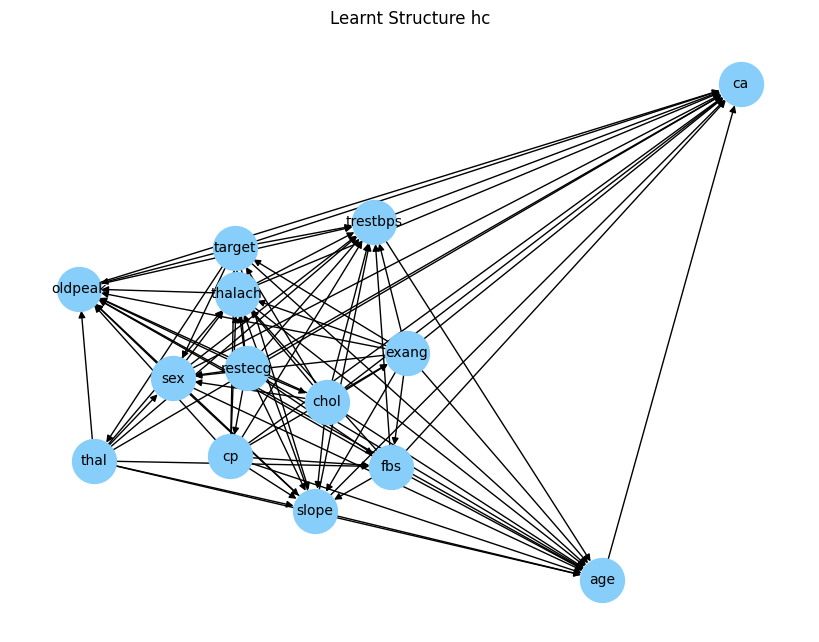

In [14]:
heart_start = time.time()

# Learn Structure
heart_structure = structure_learning(train_dheart, "hc", "k2", 2000000, dataset_name="Heart")

# Learn parameters
param_heart_structure = bn.parameter_learning.fit(heart_structure, train_dheart)

heart_train_time = time.time() - heart_start 

### **Inference**

In [ ]:
# Call infer_and_evaluate to obtain metrics and predictions
h_metrics, y_pred_heart, y_probs_heart = infer_and_evaluate(test_dheart, param_heart_structure, heart_train_time, model_name='BayesianNetwork', labels = True)
h_metrics

[bnlearn]> Remaining columns for inference: 13


100%|██████████| 157/157 [00:02<00:00, 74.84it/s]


{'Model': 'BayesianNetwork',
 'Balanced Accuracy': 0.9659,
 'F1 Score': 0.9697,
 'AUC': 0.9659,
 'Brier Score': 0.0341,
 'KL Divergence': 0.0,
 'Expected Calibration Loss': 0.4397,
 'Training Time (s)': '64.457 s',
 'Inference Time (s)': '2.1081 s'}

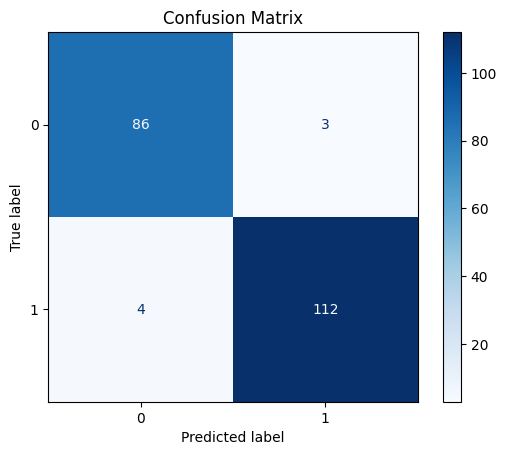

In [ ]:
# Display confusion matrix
y_true_heart = test_dheart["target"]
cm = confusion_matrix(y_true_heart, y_pred_heart)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

## **Fraud Dataset**

In [25]:
# Load the dataset
frauddata = pd.read_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/synthetic_fraud_dataset.csv')

### **EDA**

This dataset is designed to help data scientists and machine learning enthusiasts develop robust fraud detection models. It contains realistic synthetic transaction data, including user information, transaction types, risk scores, and more, making it ideal for binary classification tasks with models like XGBoost and LightGBM.

1. Transaction_ID
2. User_ID
3. Transaction_Amount
4. Transaction_Type
5. Timestamp
6. Account_Balance
7. Device_Type
8. Location
9. Merchant_Category
10. IP_Address_Flag
11. Previous_Fraudulent_Activity
12. Daily_Transaction_Count
13. Avg_Transaction_Amount_7d
14. Failed_Transaction_Count_7d
15. Card_Type
16. Card_Age
17. Transaction_Distance
18. Authentication_Method
19. Risk_Score
20. Is_Weekend
21. Fraud_Label

[Kaggle - Fraud Detection Transactions Dataset, https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset]

In [20]:
frauddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [21]:
frauddata.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [26]:
# Rename target column
frauddata.rename(columns={'Fraud_Label':'target'}, inplace=True)

# Drop ID columns
frauddata = frauddata.drop(columns=['Transaction_ID', 'User_ID', 'Timestamp'])
frauddata

,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,target
0,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,31.28,POS,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,45.05,Online,76960.11,Mobile,Tokyo,Clothing,0,0,2,389.00,3,Amex,98,1537.54,PIN,0.1493,1,0
49996,126.15,POS,28791.75,Mobile,Tokyo,Clothing,0,0,13,434.95,4,Visa,93,2555.72,Biometric,0.3653,0,1
49997,72.02,Online,29916.41,Laptop,Mumbai,Clothing,0,1,1,369.15,2,Visa,114,4686.59,Biometric,0.5195,0,0
49998,64.89,Bank Transfer,67895.67,Mobile,Tokyo,Electronics,0,0,13,242.29,4,Discover,72,4886.92,Biometric,0.7063,0,1


In [27]:
# Identify continuous and discrete columns
fraud_cont = ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score']
fraud_disc = ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Failed_Transaction_Count_7d', 
              'Card_Type', 'Authentication_Method', 'Is_Weekend', 'Fraud_Label']

print('Continuous columns: ', fraud_cont)
print('Discrete columns: ', fraud_disc)

Continuous columns:  ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score']
Discrete columns:  ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Failed_Transaction_Count_7d', 'Card_Type', 'Authentication_Method', 'Is_Weekend', 'Fraud_Label']


In [28]:
# Split the dataset into training and testing sets
train_fraud, test_fraud = train_test_split(frauddata, test_size=0.2, random_state=7)

### **5-Fold Cross-Validation**

In [32]:
# Define the scoring functions for grid search
scoring = ['aic', 'bic','k2', 'bdeu']

# Split training set in 5 folds 
fkf = KFold(n_splits=5, shuffle=True, random_state=7)

# List of metrics of interest
metric_keys = [
    "Balanced Accuracy",
    "F1 Score",
    "AUC",
    "Brier Score",
    "KL Divergence",
    "Expected Calibration Loss",
    "Training Time (s)",
    "Inference Time (s)"
]

In [33]:
all_results = {}
# Iterate over the scoring functions and for each of them perform cross-validation
for s in scoring: 

    # Initialize a dictionary to store the values per fold of each metric 
    results_summary = {key: [] for key in metric_keys}
    
    print(f"\n==================== SCORING: {s.upper()} ====================")

    n_folds = fkf.get_n_splits()

    for i, (train_idx, test_idx) in enumerate(fkf.split(train_fraud), start=1):
        train_df = train_fraud.iloc[train_idx]
        test_df = train_fraud.iloc[test_idx]

        print(f"\n----- Fold {i}/{n_folds} -----")
        
        # Call BayesianNetworkPipeline using s as the scoring method for structure learning
        metrics = BayesianNetworkPipeline(train_df, test_df, fraud_cont, nbins=[3,3,3,3,3,3,3], method='hc', scoring=s)

        # Extract values for metrics
        for key in metric_keys:

            # Extract numeric value from string
            if key in ["Training Time (s)", "Inference Time (s)"]:            
                value = float(metrics[key].replace(" s", "").strip())

            else: 
                value = float(metrics[key])
            
            # Append the metric 
            results_summary[key].append(value)
    
    # Compute the mean for each metric
    mean_metrics = {key: round(np.mean(values), 4) for key, values in results_summary.items()}
    all_results[s] = mean_metrics

# Summary of grid search
print("\n==================== FINAL SUMMARY ====================")
for s, metrics in all_results.items():
    print(f"\nScoring: {s.upper()}")
    for key, val in metrics.items():
        print(f"{key}: {val}")


==================== SCORING: AIC ====================

----- Fold 1/5 -----


TypeError: structure_learning() got an unexpected keyword argument 'verbose'

### **Pre-Processing**

In [29]:
# Fit the discretizer on the training set
discretizer_fraud, train_dfraud = discretize_fit(train_fraud, fraud_cont, [3,3,3,3,3,3,3], transform=True)

# Trasnsform the test set
test_dfraud = discretize_transform(test_fraud, fraud_cont, discretizer_fraud)

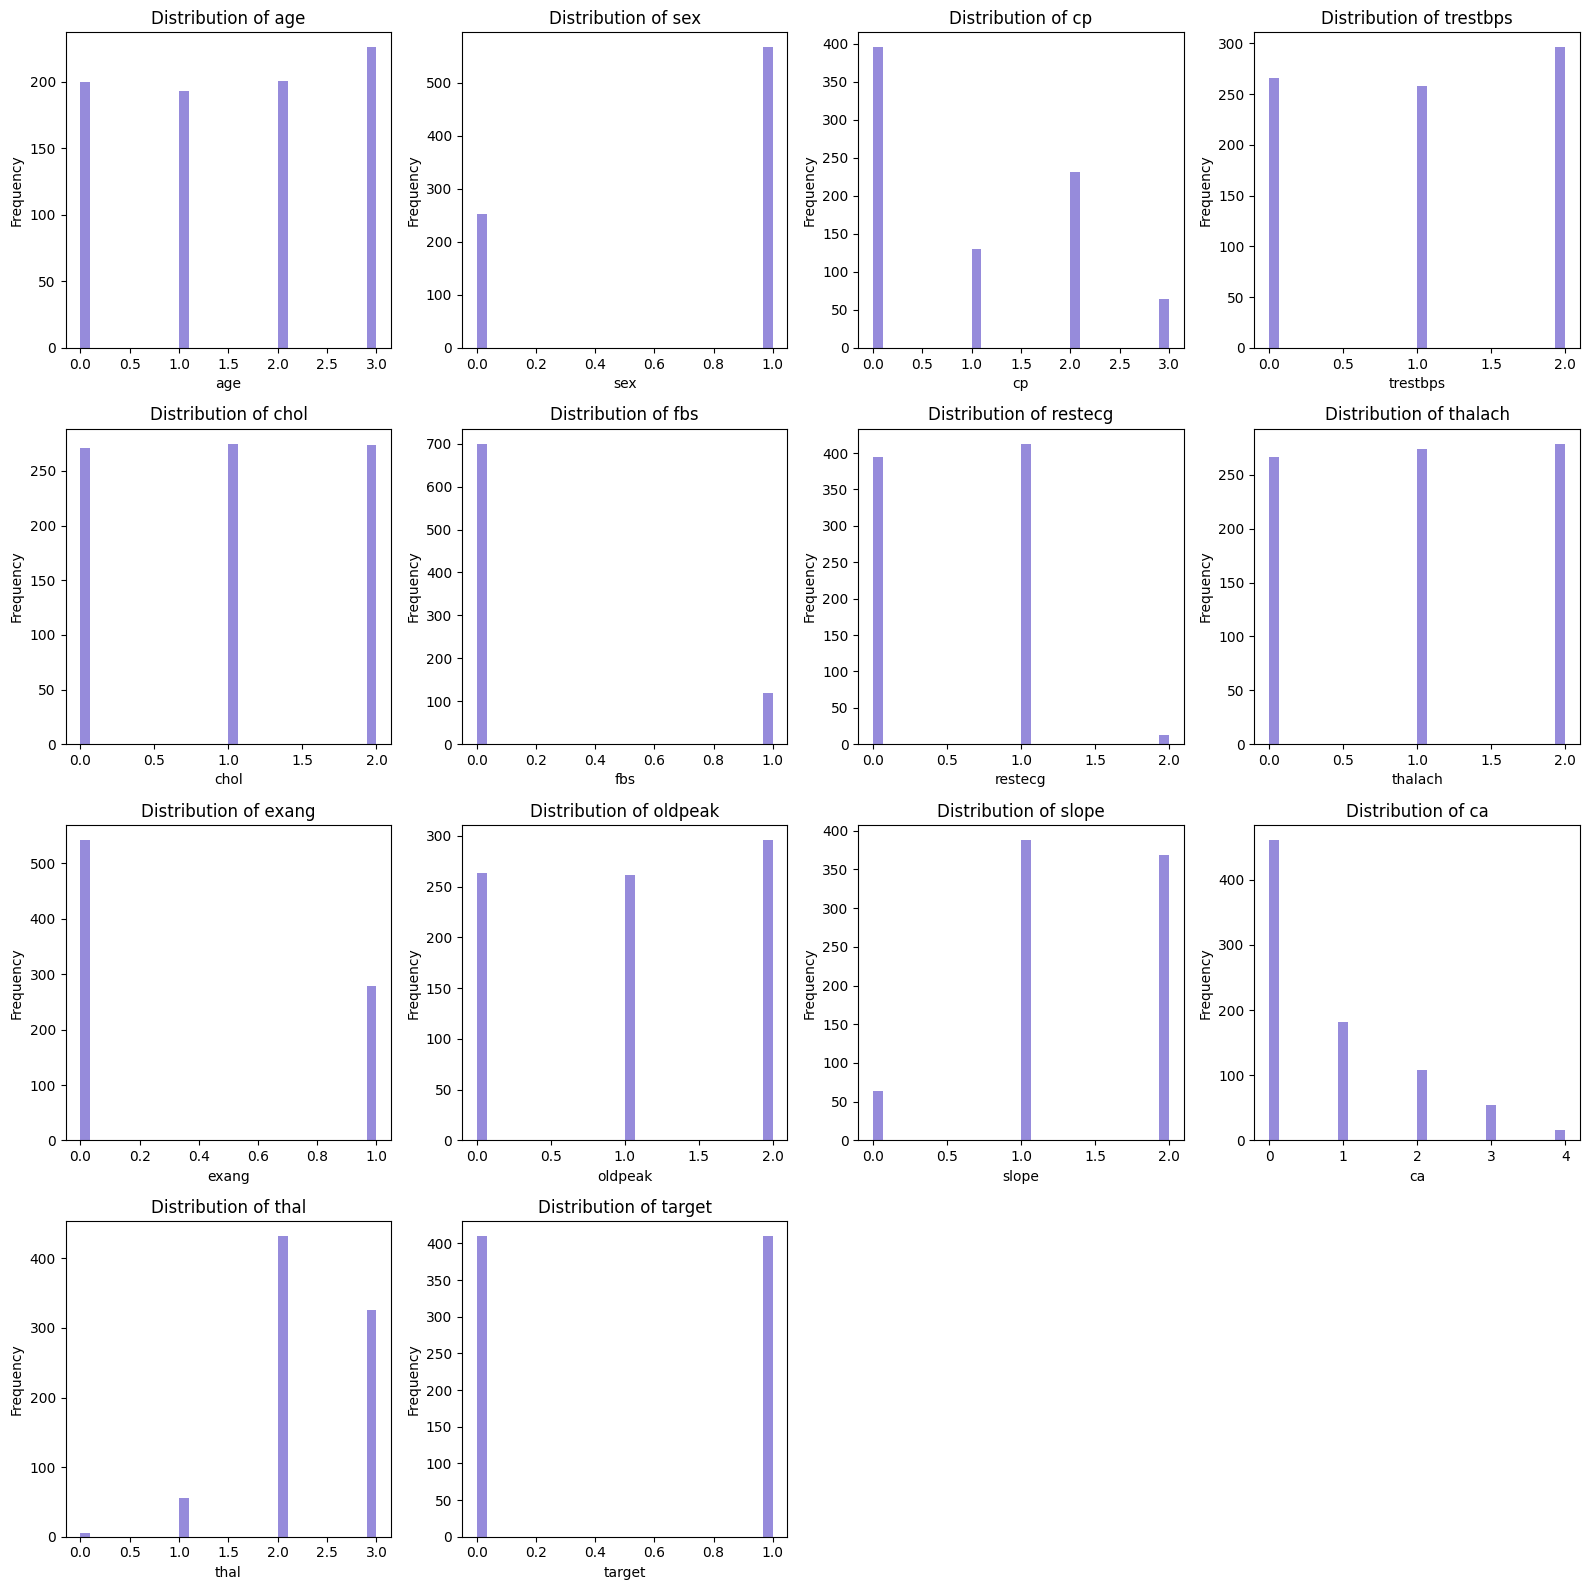

In [30]:
# Visualize the discretized variables in the train set:
plot_distributions(train_dheart, train_dheart.columns, color='slateblue')


### **Structure and Parameter Learning**

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x71eea9adf150>, 'model_edges': [('Risk_Score', 'Failed_Transaction_Count_7d'), ('Risk_Score', 'target'), ('target', 'Failed_Transaction_Count_7d')], 'adjmat': target                        Transaction_Amount  Transaction_Type  \
source                                                               
Transaction_Amount                         False             False   
Transaction_Type                           False             False   
Account_Balance                            False             False   
Device_Type                                False             False   
Location                                   False             False   
Merchant_Category                          False             False   
IP_Address_Flag                            False             False   
Prev

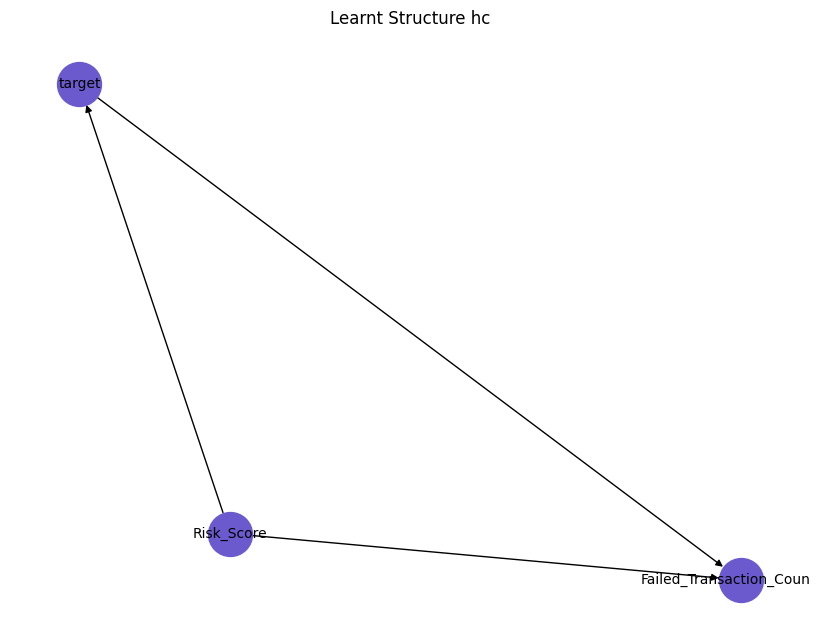

In [ ]:
fraud_start = time.time()

# Learn Structure
fraud_structure = structure_learning(train_dfraud, "hc", "bic", 2000000, dataset_name="Fraud", color = "slateblue")

# Learn parameters
param_fraud_structure = bn.parameter_learning.fit(fraud_structure, train_dfraud)

fraud_train_time = time.time() - fraud_start 

### **Inference**

In [ ]:
# Call infer_and_evaluate to obtain metrics and predictions
f_metrics, y_pred_fraud, y_probs_fraud = infer_and_evaluate(test_dfraud, param_fraud_structure, fraud_train_time, model_name='BayesianNetwork', labels = True)
f_metrics

[bnlearn]> Remaining columns for inference: 2


100%|██████████| 15/15 [00:00<00:00, 1987.26it/s]


In [ ]:
# Display confusion matrix
y_true_fraud = test_dfraud["target"]
cm = confusion_matrix(y_true_fraud, y_pred_fraud)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1]) 
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix")
plt.show()

{'Model': 'BayesianNetwork',
 'Balanced Accuracy': 0.8093,
 'F1 Score': 0.7644,
 'AUC': 0.8093,
 'Brier Score': 0.1218,
 'KL Divergence': 0.0,
 'Expected Calibration Loss': 0.5468,
 'Training Time (s)': '3.1 s',
 'Inference Time (s)': '0.0155 s'}

## **Prova Pipeline Heart**

In [ ]:
train_heart, test_heart = train_test_split(heartdata, test_size=0.2, random_state=7)

metrics = BayesianNetworkPipeline(train_heart, test_heart, heart_cont, [4,3,3,3,3], method='hc', scoring='aic', naive=False)

[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x731b42d66110>, 'model_edges': [('age', 'thalach'), ('sex', 'trestbps'), ('sex', 'cp'), ('sex', 'restecg'), ('cp', 'exang'), ('cp', 'thalach'), ('cp', 'slope'), ('cp', 'oldpeak'), ('cp', 'trestbps'), ('trestbps', 'age'), ('trestbps', 'ca'), ('trestbps', 'slope'), ('trestbps', 'fbs'), ('chol', 'ca'), ('chol', 'exang'), ('chol', 'trestbps'), ('chol', 'sex'), ('chol', 'target'), ('fbs', 'age'), ('fbs', 'ca'), ('thalach', 'restecg'), ('thalach', 'exang'), ('exang', 'restecg'), ('oldpeak', 'slope'), ('oldpeak', 'fbs'), ('slope', 'thalach'), ('slope', 'restecg'), ('slope', 'fbs'), ('ca', 'age'), ('thal', 'target'), ('thal', 'sex'), ('thal', 'oldpeak'), ('thal', 'cp'), ('thal', 'chol'), ('target', 'cp'), ('target', 

100%|██████████| 157/157 [00:00<00:00, 981.77it/s]


{'Model': 'BayesianNetwork',
 'Balanced Accuracy': 0.9189,
 'F1 Score': 0.9251,
 'AUC': 0.9189,
 'Brier Score': 0.0829,
 'KL Divergence': 0.0,
 'Expected Calibration Loss': 0.2874,
 'Training Time (s)': '1.9532 s',
 'Inference Time (s)': '0.1681 s'}